In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import median_abs_deviation as mad

In [2]:
#CXCORR function
def get_coarse_xcorr(f1,f2,chans=None):
    """ Get coarse xcorr of each channel of two channelized timestreams.
    The xcorr is 0-padded, so length of output is twice the original length (shape[0]).
    
    Parameters
    ----------
    f1, f2 : ndarray of complex64
        First and second timestreams. Both n_spectrum x n_channel complex array.
    chans: tuple of int
        Channels (columns) of f1 and f2 that should be correlated.
    
    Returns
    -------
    ndarray of complex128
        xcorr of each channel's timestream. 2*n_spectrum x n_channel complex array.
    """
    if chans is None:
        chans = np.arange(f1.shape[1])
    Nsmall=f1.shape[0]
    print("Shape of passed channelized timestream =", f1.shape)
    xcorr=np.zeros((len(chans),2*Nsmall),dtype='complex128')
    win=np.hamming(2*Nsmall)
    wt = np.zeros(2*Nsmall)
    wt[:Nsmall] = 1
    n_avg = np.fft.irfft(np.fft.rfft(wt)*np.conj(np.fft.rfft(wt)))
    for i,chan in enumerate(chans):
        print("processing chan", chan)
#         p0=np.zeros(2*Nsmall,dtype='complex128')
#         p1=np.zeros(2*Nsmall,dtype='complex128')
#         p0[:Nsmall]=f1[:Nsmall,chan].flatten()
#         p1[:Nsmall]=f2[:Nsmall,chan].flatten()
#         xcorr[:,i]=np.fft.ifft(np.fft.fft(p0)*np.conj(np.fft.fft(p1)))
        xcorr[i, :] = np.fft.ifft(
                        np.fft.fft(np.hstack([f1[:, chan].flatten(), np.zeros(Nsmall, dtype="complex128")]))
                        * np.conj(
                            np.fft.fft(np.hstack([f2[:, chan].flatten(), np.zeros(Nsmall, dtype="complex128")]))
                        )
                    )
#         xcorr[Nsmall-bb:Nsmall+bb,i]=np.nan
        xcorr[i, :]=xcorr[i, :]/n_avg/4096
    print(xcorr.shape)
    
    return np.ma.masked_invalid(xcorr)

    

#make visibilities with osamp1
def get_vis(d1, d2, nspec, nchans, blocksize, start=0, shift=0):
    nblocks = nspec//blocksize
    vis = np.zeros((nblocks, nchans), dtype="complex128")
    print("nblocks", nblocks)
    for i in range(nblocks):
        ix = start * blocksize + i * blocksize
        y1 = d1[ix : ix + blocksize, :]
        y2 = d2[ix + shift : ix + shift + blocksize, :]
        xc_small = y1 * np.conj(y2)
        vis[i, :] = np.mean(xc_small, axis=0)
    return vis  

In [3]:
#PLOTTING STUFF
plt.style.use('seaborn-v0_8-ticks')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 200
})

# Baseband Data

In [4]:
data_loc_single = "/project/rrg-sievers/mohanagr/albatros_test_data/spectra_1830_1840_4096_24000_0.05_1.00e-10_20260408_192234.npz"
data_loc_multi = "/scratch/thomasb/mohan/spectra_multicarrier_1830_1890_4096_24000_0.05_1.00e-10_20260706_180425.npz"
with np.load(data_loc_multi) as f:
    spec1 = f["spectra1"]
    spec2 = f["spectra2"]     
    delays = f["delays"]*4

In [5]:
print(spec1.shape)
print(spec2.shape)
print(delays.shape)

(12000000, 60)
(12000000, 60)
(12000000,)


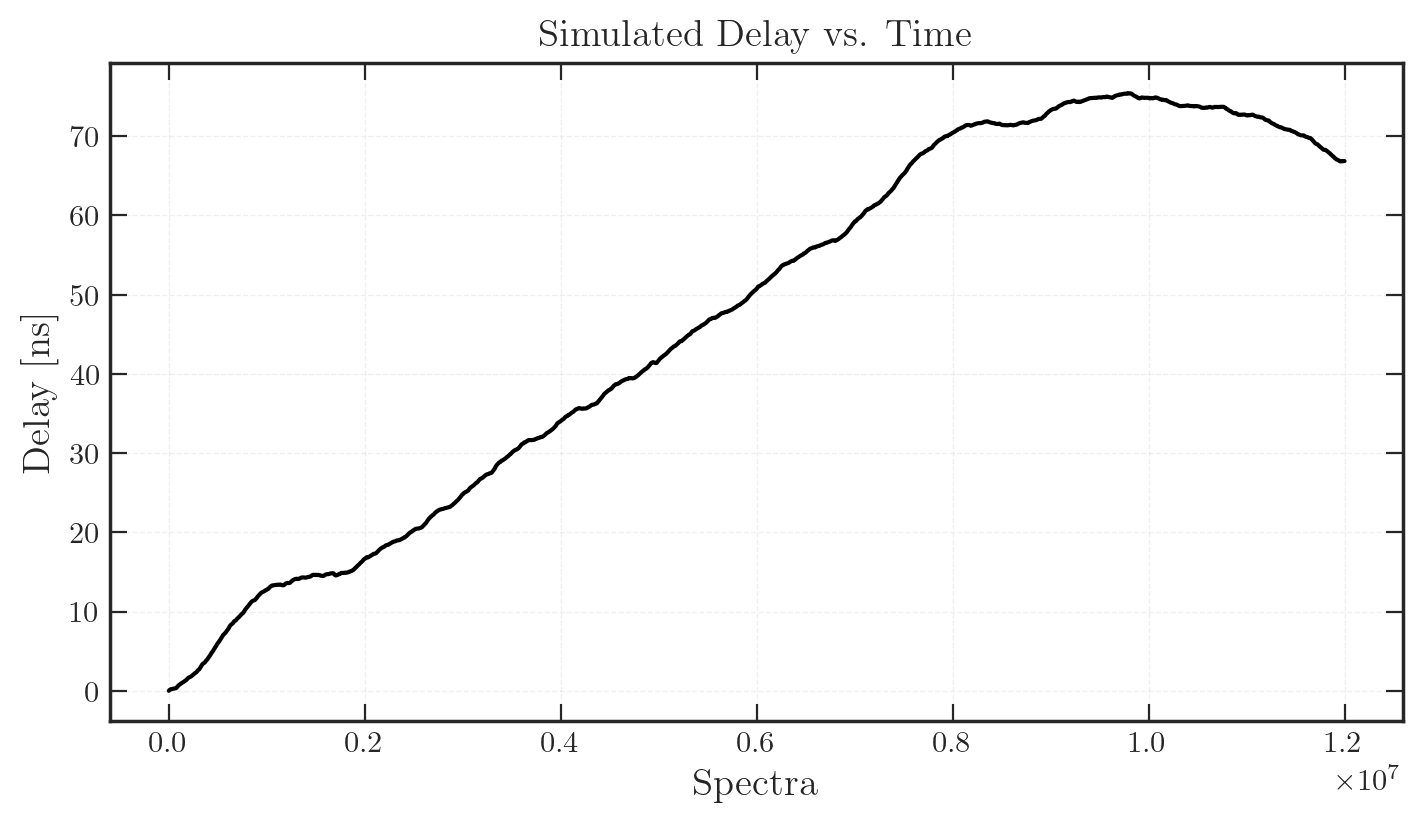

In [6]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(delays,color='k',lw=1.5,)
T_ACCLEN = 4096/250e6
ax.set_xlabel(r"Spectra")
ax.set_ylabel(r"Delay [ns]")
ax.set_title(r"Simulated Delay vs. Time")
ax.tick_params(direction='in',top=True,right=True)

# Optional: light grid for readability
ax.grid(alpha=0.3,linestyle='--',linewidth=0.5)
plt.show()

## Get the CXCORR

In [7]:
chan_slice = [4, 15, 25, 35, 45, 55]

In [8]:
#take the cxcorr but only for channels that have actual signal in them
cxcorr = get_coarse_xcorr(spec1,spec2,chan_slice)
cxcorr = np.fft.fftshift(cxcorr,axes=1)
print(cxcorr.shape)

Shape of passed channelized timestream = (12000000, 60)
processing chan 4
processing chan 15
processing chan 25
processing chan 35
processing chan 45
processing chan 55
(6, 24000000)
(6, 24000000)


Plot some stuff

-5
-5
-5
-5
-5
-5


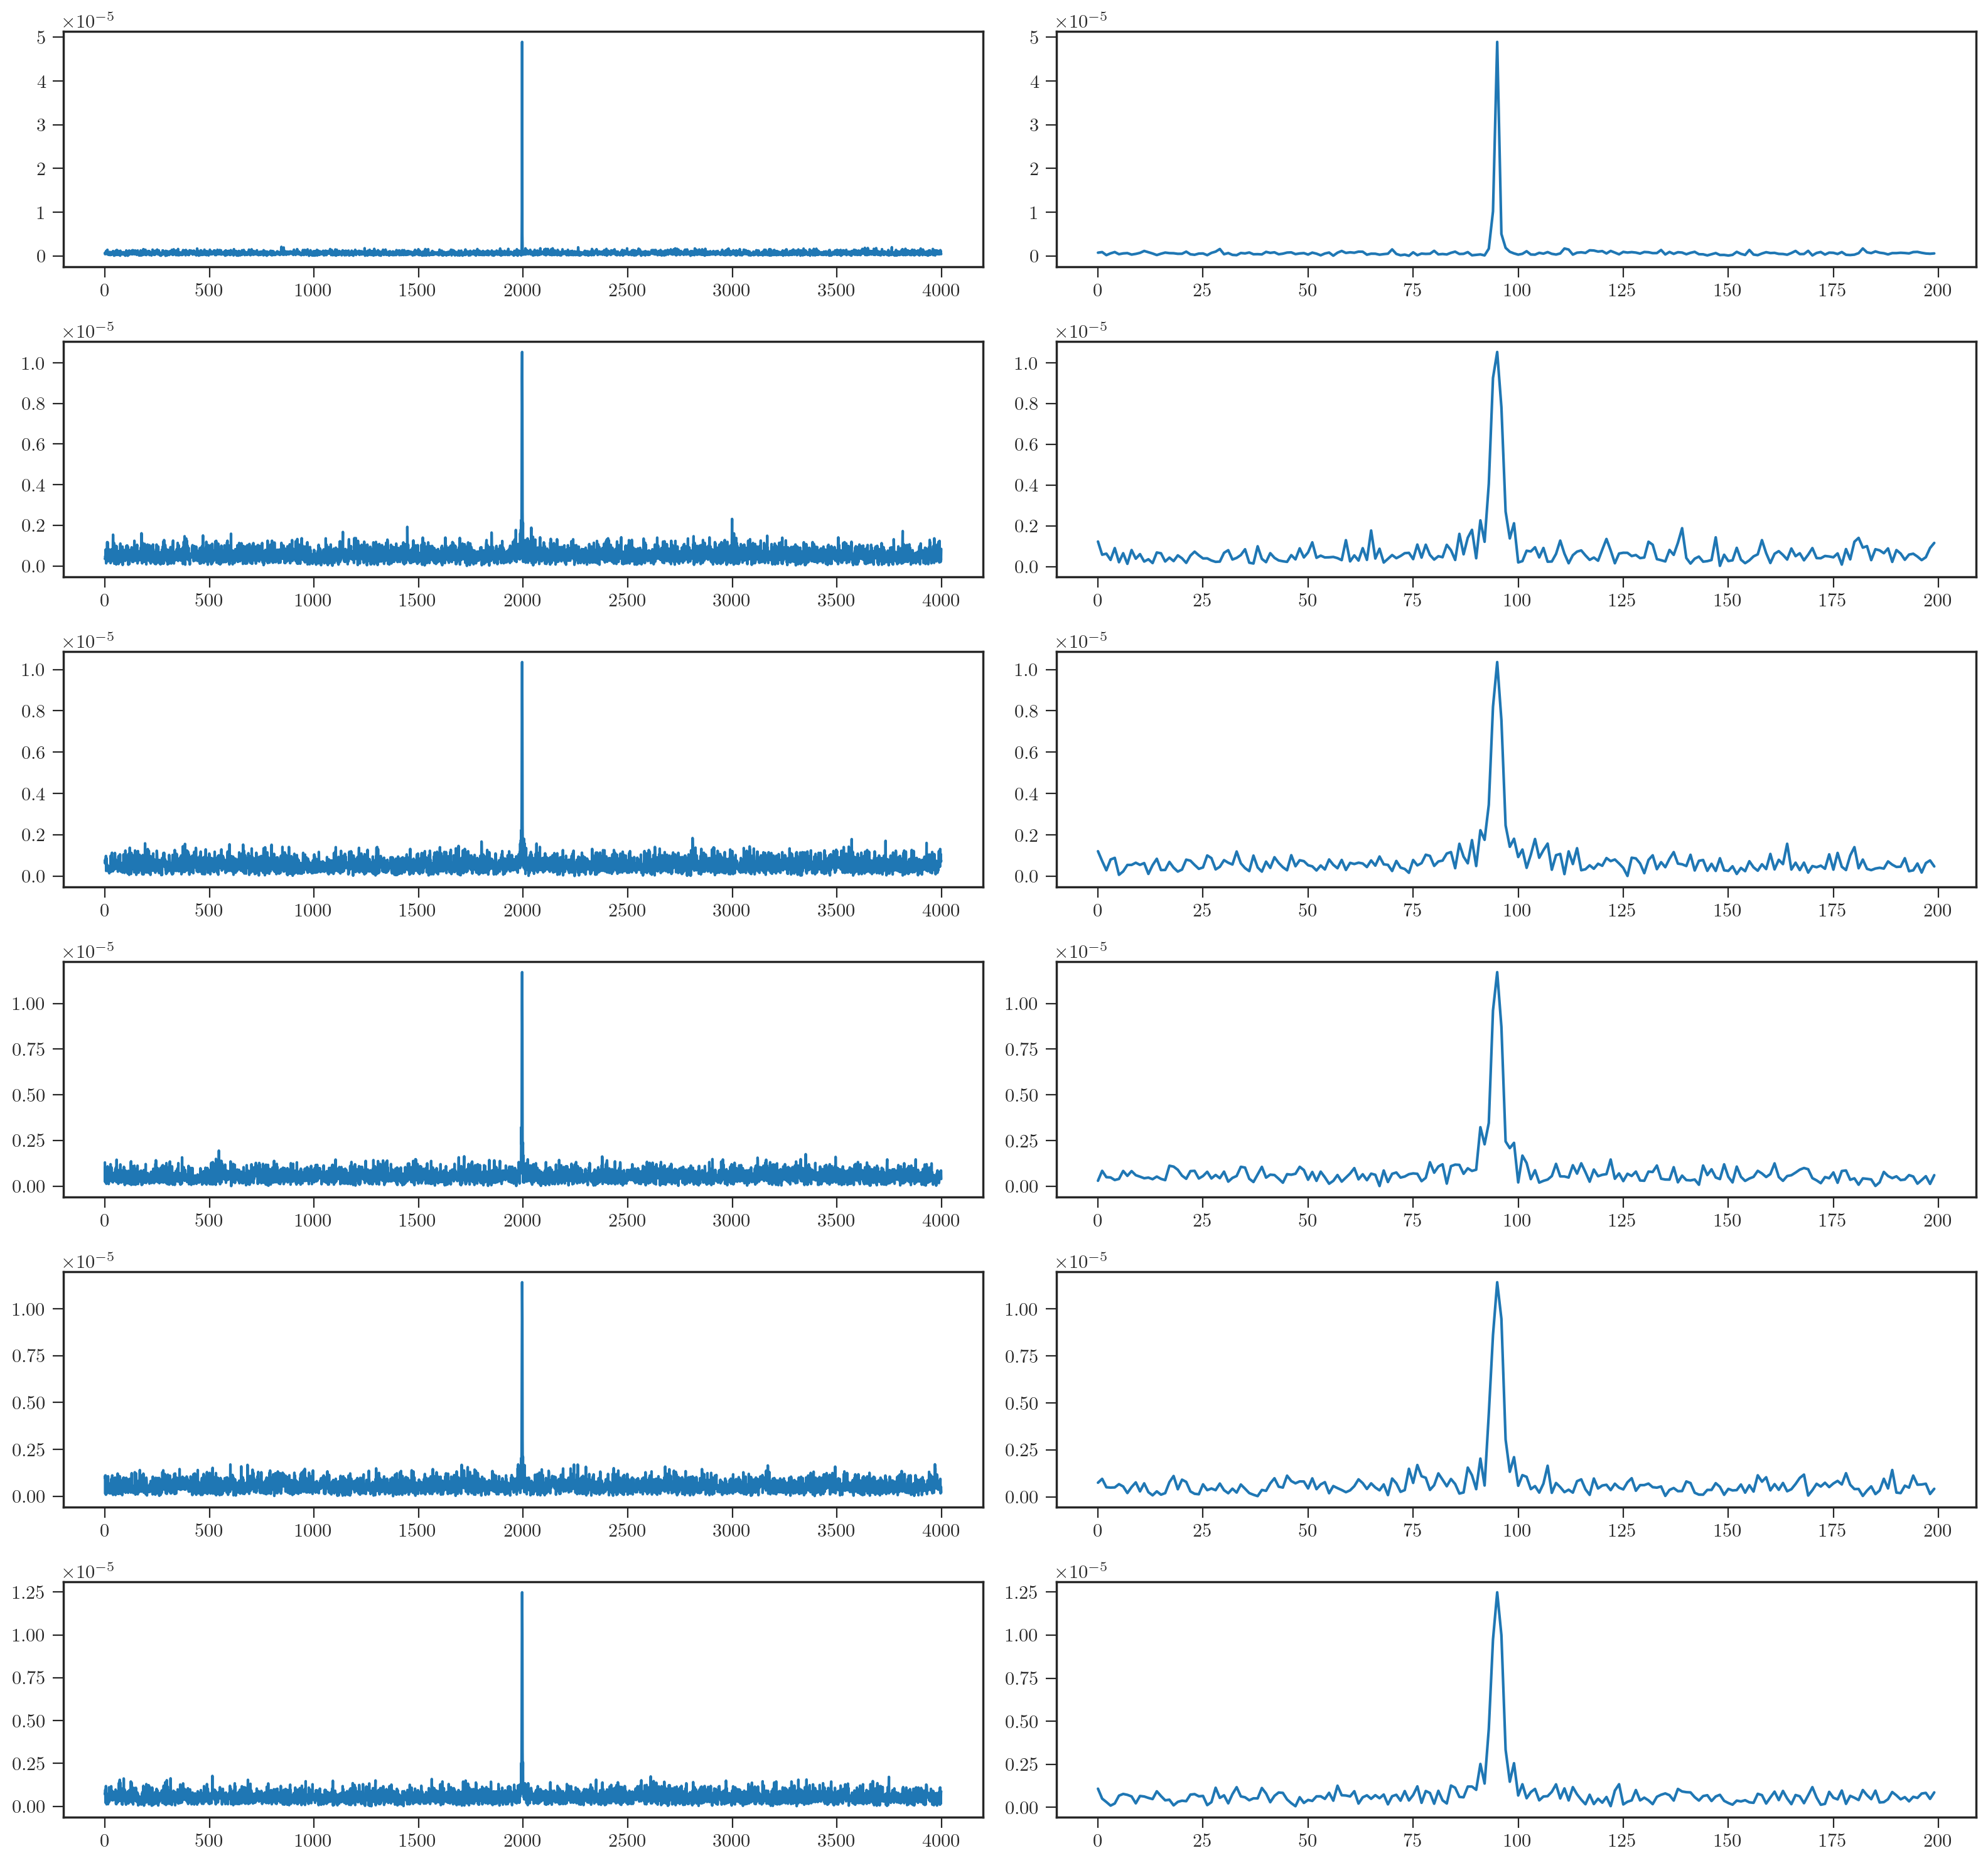

In [28]:
#Plotting the cxcorr
nplots = len(chan_slice)

fig, ax = plt.subplots(nplots, 2, figsize=(16,15))
for i in range(nplots):
    N = cxcorr.shape[1]
    dN=2000
    stamp1 = slice(N//2-dN,N//2+dN)
    stamp2 = slice(N//2-100,N//2+100)
    cx1 = np.abs(cxcorr[i,stamp1])
    cx2 = np.abs(cxcorr[i,stamp2])
    peak = np.argmax(cx1) - dN
    print(peak)
    ax[i, 0].plot(cx1)
    ax[i, 1].plot(cx2)
#plt.axvline(dN-5,c='black')
plt.tight_layout()

In [ ]:
#get the SNR
for i in range(nplots):
    noise_real, noise_imag = mad(np.real(cxcorr[i,stamp1])), mad(np.imag(cxcorr[i,stamp1]))
    snr_real = np.max(np.abs(np.real(cxcorr[i,stamp1])))/noise_real
    snr_per_sample = snr_real/np.sqrt(spec1.shape[0])
    print(f'======index {i}')
    print('real snr', snr_real)
    print('in dB', 10*np.log10(snr_real))
    print('per sample snr', snr_per_sample)

======index 0
real snr 39.81870457394422
in dB 16.000871269736827
per sample snr 0.011494669902274438
======index 1
real snr 30.05582425229867
in dB 14.779286425796812
per sample snr 0.00867636911139036
======index 2
real snr 29.99503683001082
in dB 14.770493995310384
per sample snr 0.008658821294079744
======index 3
real snr 34.39675678678156
in dB 15.365174955946308
per sample snr 0.00992948839504921
======index 4
real snr 37.44960010638561
in dB 15.734471845850894
per sample snr 0.010810768351232786
======index 5
real snr 41.14881173042859
in dB 16.14357298445761
per sample snr 0.01187863876469809


## Get the vis

In [21]:
#get the visibilities with and without alignment

#acclen
blocksize = 4096
#total size of data
nblocks = spec1.shape[0]//blocksize
vis_uncorr = np.zeros((nblocks, spec1.shape[1]), dtype="complex128")
vis_corr = np.zeros((nblocks, spec1.shape[1]), dtype="complex128")

shift=5
print("nblocks",nblocks)
print('getting corrected vis')
for i in range(nblocks):
    ix = i * blocksize
    y1 = spec1[ix : ix + blocksize, :]
    y2 = spec2[ix + shift : ix + shift + blocksize, :]
    xc_small = y1 * np.conj(y2)
    vis_corr[i, :] = np.mean(xc_small, axis=0)
phase_corr = np.angle(vis_corr)

print('getting uncorrected vis')
for i in range(nblocks):
    ix = i * blocksize
    y1 = spec1[ix : ix + blocksize, :]
    y2 = spec2[ix : ix + blocksize, :]
    xc_small = y1 * np.conj(y2)
    vis_uncorr[i, :] = np.mean(xc_small, axis=0)
phase_uncorr = np.angle(vis_uncorr)

nblocks 2929
getting corrected vis
getting uncorrected vis


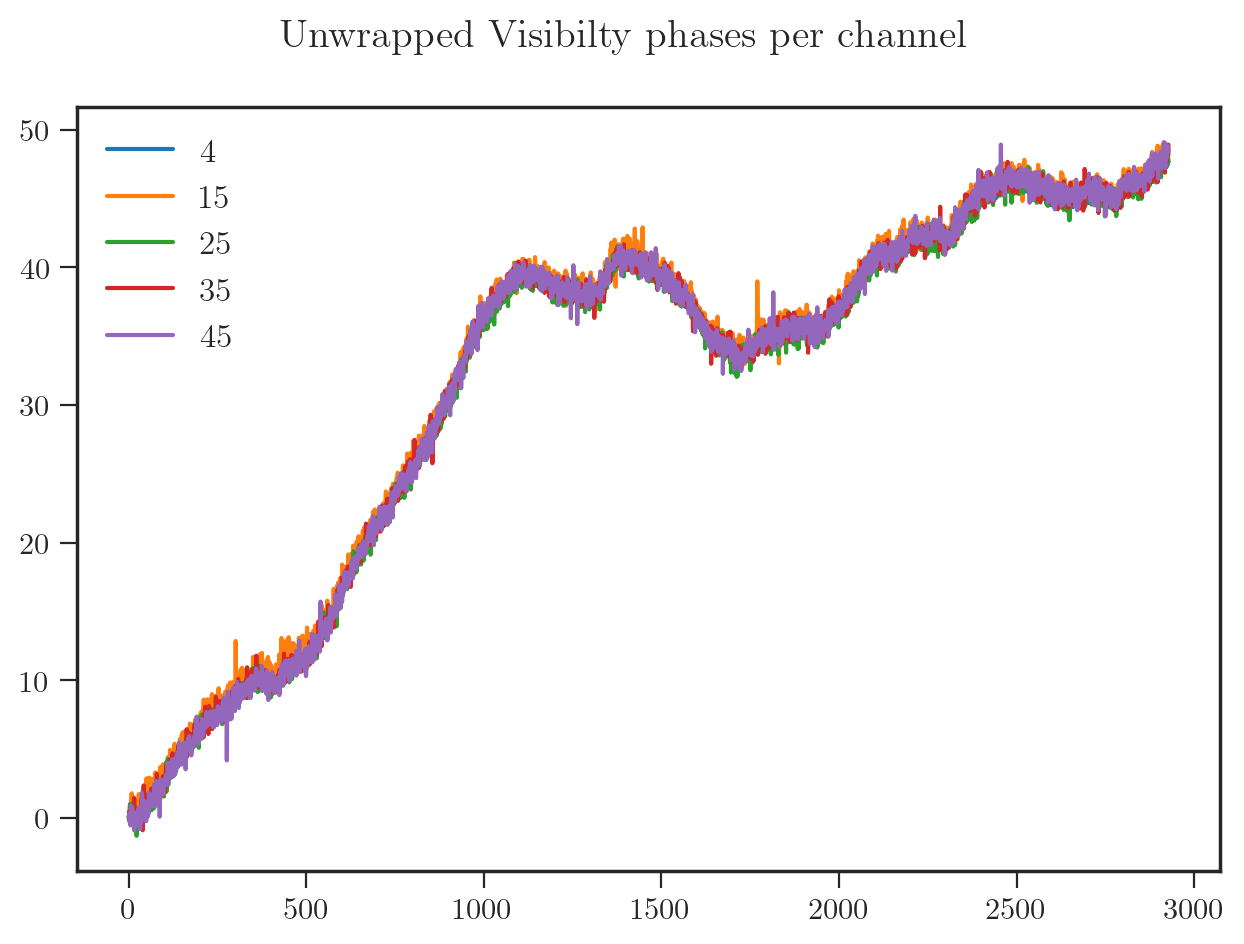

In [ ]:
#sanity check that gets unwrapped visibilities per channel

# phase_sliced = np.unwrap(phase_corr[:, chan_slice], axis=0)
# for i in range(len(chan_slice)):
#     plt.plot((phase_sliced[:,i]-phase_sliced[0,i])/(2*np.pi*0.11), label=chan_slice[i])
# plt.legend()
# plt.suptitle('Unwrapped Visibilty phases per channel')
# plt.tight_layout()

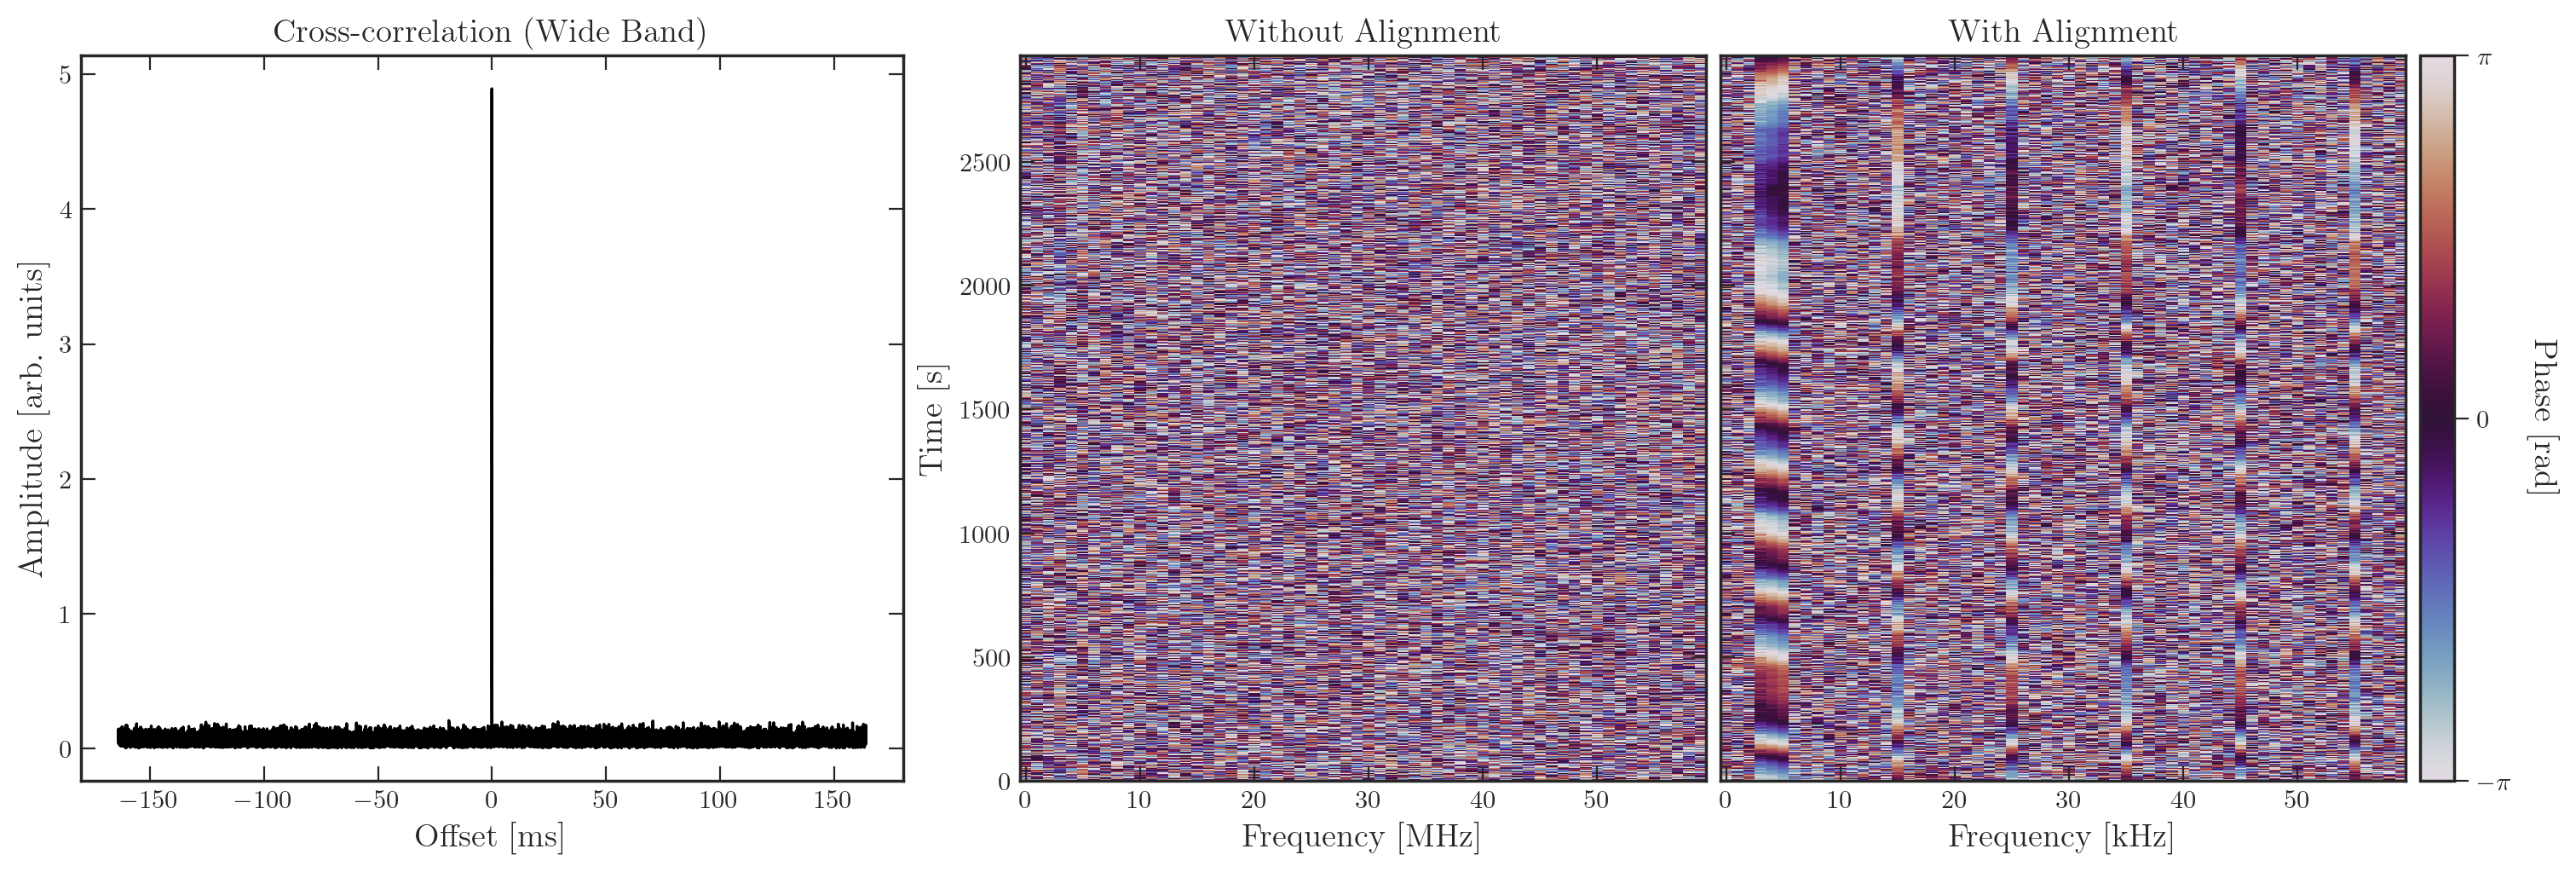

In [30]:
# Correlation window
N = cxcorr.shape[1]
dN = 10000
T_SPECTRA = 4096 / 250e6

stamp = slice(N // 2 - dN, N // 2 + dN)
cx = np.abs(cxcorr[0, stamp])

# Common phase scale
vmin = -np.pi
vmax = np.pi

fig = plt.figure(figsize=(15, 5), constrained_layout=True)

# Layout: [cxcorr | phase_uncorr | phase_corr | colorbar]
gs = fig.add_gridspec(
    1, 4,
    width_ratios=[1.2, 1, 1, 0.05]
)

ax_cx   = fig.add_subplot(gs[0])
ax_unc  = fig.add_subplot(gs[1])
ax_corr = fig.add_subplot(gs[2], sharey=ax_unc)
cax     = fig.add_subplot(gs[3])

#left
ax_cx.plot(np.arange(-dN, dN) * T_SPECTRA * 1e3,np.abs(cx) * 1e5,color='k',lw=1.2)
#ax_cx.set_title(rf"Cross-correlation (Peak = {peak})")
ax_cx.set_title(rf"Cross-correlation (Wide Band)")
ax_cx.set_xlabel(r"Offset [ms]")
ax_cx.set_ylabel(r"Amplitude [arb. units]")

#middle
im = ax_unc.imshow(phase_uncorr,aspect='auto',cmap='twilight',interpolation='nearest',origin='lower',vmin=vmin,vmax=vmax)
ax_unc.set_title(r"Without Alignment")
ax_unc.set_xlabel(r"Frequency [MHz]")
ax_unc.set_ylabel(r"Time [s]")

#right
ax_corr.imshow(phase_corr,aspect='auto',cmap='twilight',interpolation='nearest',origin='lower',vmin=vmin,vmax=vmax)
ax_corr.set_title(r"With Alignment")
ax_corr.set_xlabel(r"Frequency [kHz]")
ax_corr.tick_params(labelleft=False)

#colorbar
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"Phase [rad]",rotation=270,labelpad=20)
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels([r"$-\pi$",r"$0$",r"$\pi$"])

#ticks
for a in [ax_cx, ax_unc, ax_corr]:
    a.tick_params(direction='in',top=True,right=True)

plt.savefig("/home/thomasb/albatros_analysis/scripts/orbcomm/paper_plots/cxcorr.png", bbox_inches="tight")
plt.show()

# Upchannelized Data

In [23]:
# with np.load("/scratch/mohanagr/raw_64_0.08_apr9.npz") as f:
#         new_spec1 = f["spec1"]
#         new_spec2 = f["spec2"]
#         new_channels = f["channels"]
with np.load("/scratch/mohanagr/raw_64_117260_117516_0.08_20260410_133544.npz") as f:
        osamp1spec1 = f["spec1"]
        osamp1spec2 = f["spec2"]
        osamp1chans = f["channels"]
with np.load("/scratch/mohanagr/raw_small_64_117260_117516_0.08_20260410_133913.npz") as f:
        osamp2spec1 = f["spec1"]
        osamp2spec2 = f["spec2"]
        osamp2chans = f["channels"]
with np.load("/scratch/mohanagr/raw_small_64_117260_117516_0.08_20260410_134742.npz") as f:
        osamp3spec1 = f["spec1"]
        osamp3spec2 = f["spec2"]
        osamp3chans = f["channels"]
osamp=64
print(osamp1chans[0]/osamp, osamp1chans[-1]/osamp)

KeyboardInterrupt: 

In [5]:
#getting the frequencies right
osamp1freqs = osamp1chans/osamp * 250e6/4096
print(osamp1freqs[0]/1e6)

111.82785034179688


In [6]:
#make visibilities

acclen = 1024

nspec, nchans = osamp1spec1.shape
osamp1vis = get_vis(osamp1spec1, osamp1spec2, nspec, nchans, acclen)
osamp1vis_corr = get_vis(osamp1spec1, osamp1spec2, nspec, nchans, acclen)

nspec, nchans = osamp2spec1.shape
osamp2vis = get_vis(osamp2spec1, osamp2spec2, nspec, nchans, acclen)
osamp2vis_corr = get_vis(osamp2spec1, osamp2spec2, nspec, nchans, acclen, shift=5)

nspec, nchans = osamp3spec1.shape
osamp3vis = get_vis(osamp3spec1, osamp3spec2, nspec, nchans, acclen)
osamp3vis_corr = get_vis(osamp3spec1, osamp3spec2, nspec, nchans, acclen, shift=5)

nblocks 183
nblocks 183
nblocks 183
nblocks 183
nblocks 183
nblocks 183


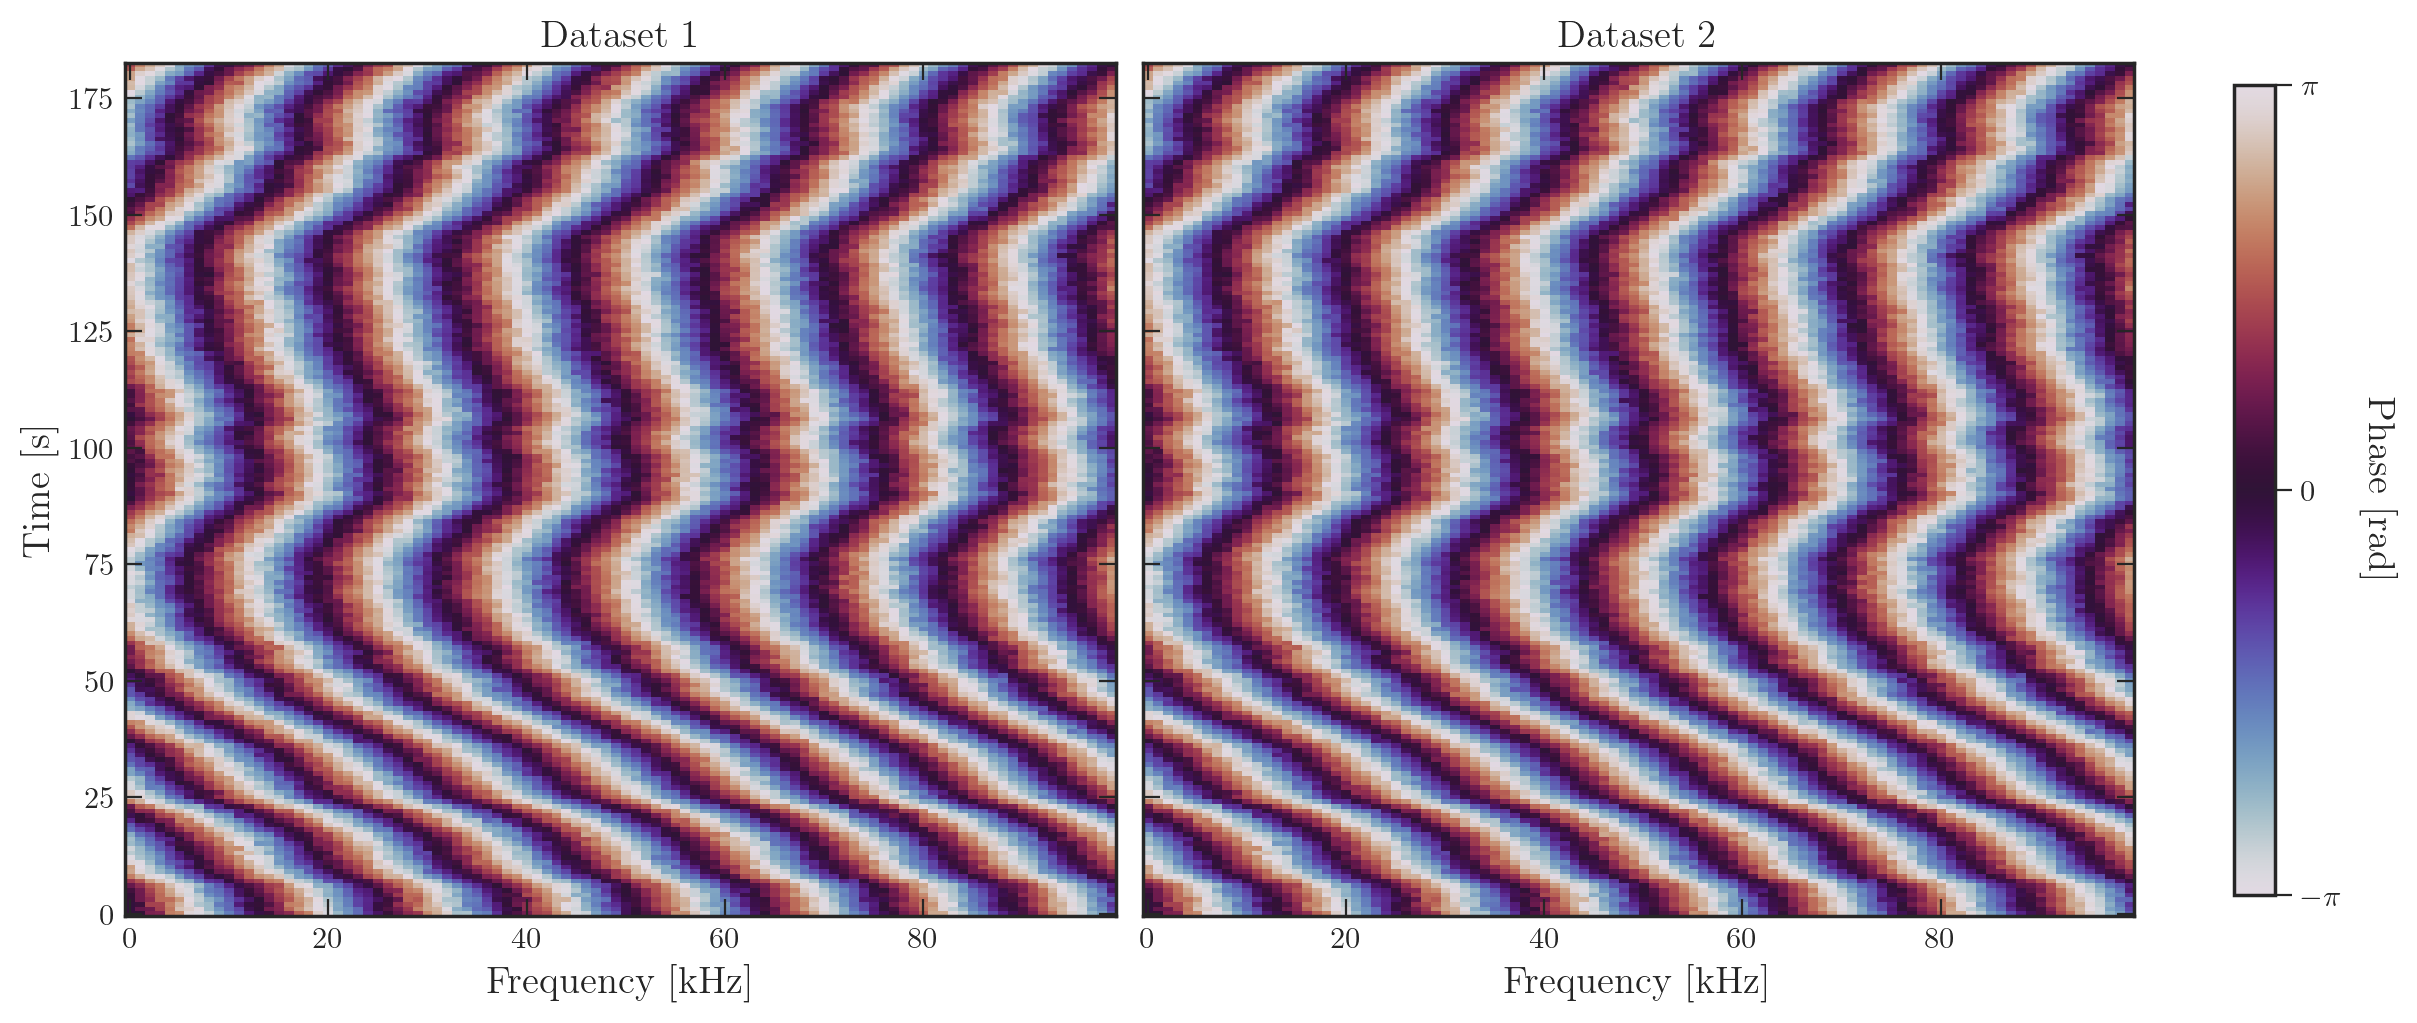

In [7]:
# Phase data
data1 = np.angle(osamp1vis[:, 70:170])
data2 = np.angle(osamp2vis[:, 70:170])

vmin, vmax = -np.pi, np.pi

# Create side-by-side figure
fig, ax = plt.subplots(1, 2,figsize=(12, 5),sharey=True,constrained_layout=True)

#left
im = ax[0].imshow(data1,aspect='auto',cmap='twilight',interpolation='nearest',origin='lower',vmin=vmin,vmax=vmax)
ax[0].set_title(r"Dataset 1")
ax[0].set_ylabel(r"Time [s]")
ax[0].set_xlabel(r"Frequency [kHz]")

#right
im = ax[1].imshow(data2,aspect='auto',cmap='twilight',interpolation='nearest',origin='lower',vmin=vmin,vmax=vmax)
ax[1].set_title(r"Dataset 2")
ax[1].set_xlabel(r"Frequency [kHz]")

# Publication-style ticks
for a in ax:
    a.tick_params(direction='in', top=True, right=True)

#colorbar
cbar = fig.colorbar(im,ax=ax,location='right',shrink=0.95)
cbar.set_label(r"Phase [rad]",rotation=270,labelpad=20)
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels([r"$-\pi$",r"$0$",r"$\pi$"])
plt.show()

In [8]:
np.savez("/scratch/thomasb/sim_finetiming/osamp1vis.npz",vis=osamp1vis,chans=osamp1chans)

# Fine Timing

In [13]:
d = np.load('/scratch/thomasb/sim_finetiming/delay_results.npz')
tau_s = -d['taus_small']
tau_0 = -d['net']
errs = d['errs'] 

In [14]:
#set global variables
osamp = 64
acclen = 1024
nspec = len(delays)
nvis = len(tau_s)

#get tau data
tau_all = tau_0 + tau_s

print('total vis', nvis)
print('total spectra from vis', nvis*osamp*acclen)
print('total spectra in delay', nspec)
print(f'coverage: {(nvis*osamp*acclen/nspec *100):.3f}%')

total vis 183
total spectra from vis 11993088
total spectra in delay 12000000
coverage: 99.942%


In [15]:
print(delays[int(acclen*osamp/2)])

0.24809219496162638


In [16]:
#the baseband spectra that correspond to the timing solution are in the CENTER of the acclen
spectra = np.arange(0.5, nvis+0.5)*osamp*acclen

#want to find where these start and stop so we can interpolate between places we actually have data
start = int(spectra[0])
end = int(spectra[-1])
print(start, end)

delays = np.asarray(delays).squeeze().astype(float)
spectra = np.asarray(spectra).squeeze().astype(float)
tau_all = np.asarray(tau_all).squeeze().astype(float)
tau_s = np.asarray(tau_all).squeeze().astype(float)

y1 = (delays[start:end]) + 82720
y1 = y1[::10]
y2_interp = np.interp(np.arange(start, end, 10), spectra, tau_s)
res = y1 - y2_interp
res_plot = res - np.mean(res)

print(res)

print(tau_0)
print(tau_s[0])

32768 11960320
[0.6422707  0.64229793 0.64227438 ... 0.63877778 0.63876757 0.63877891]
[82719.60582149]
82719.60582149029


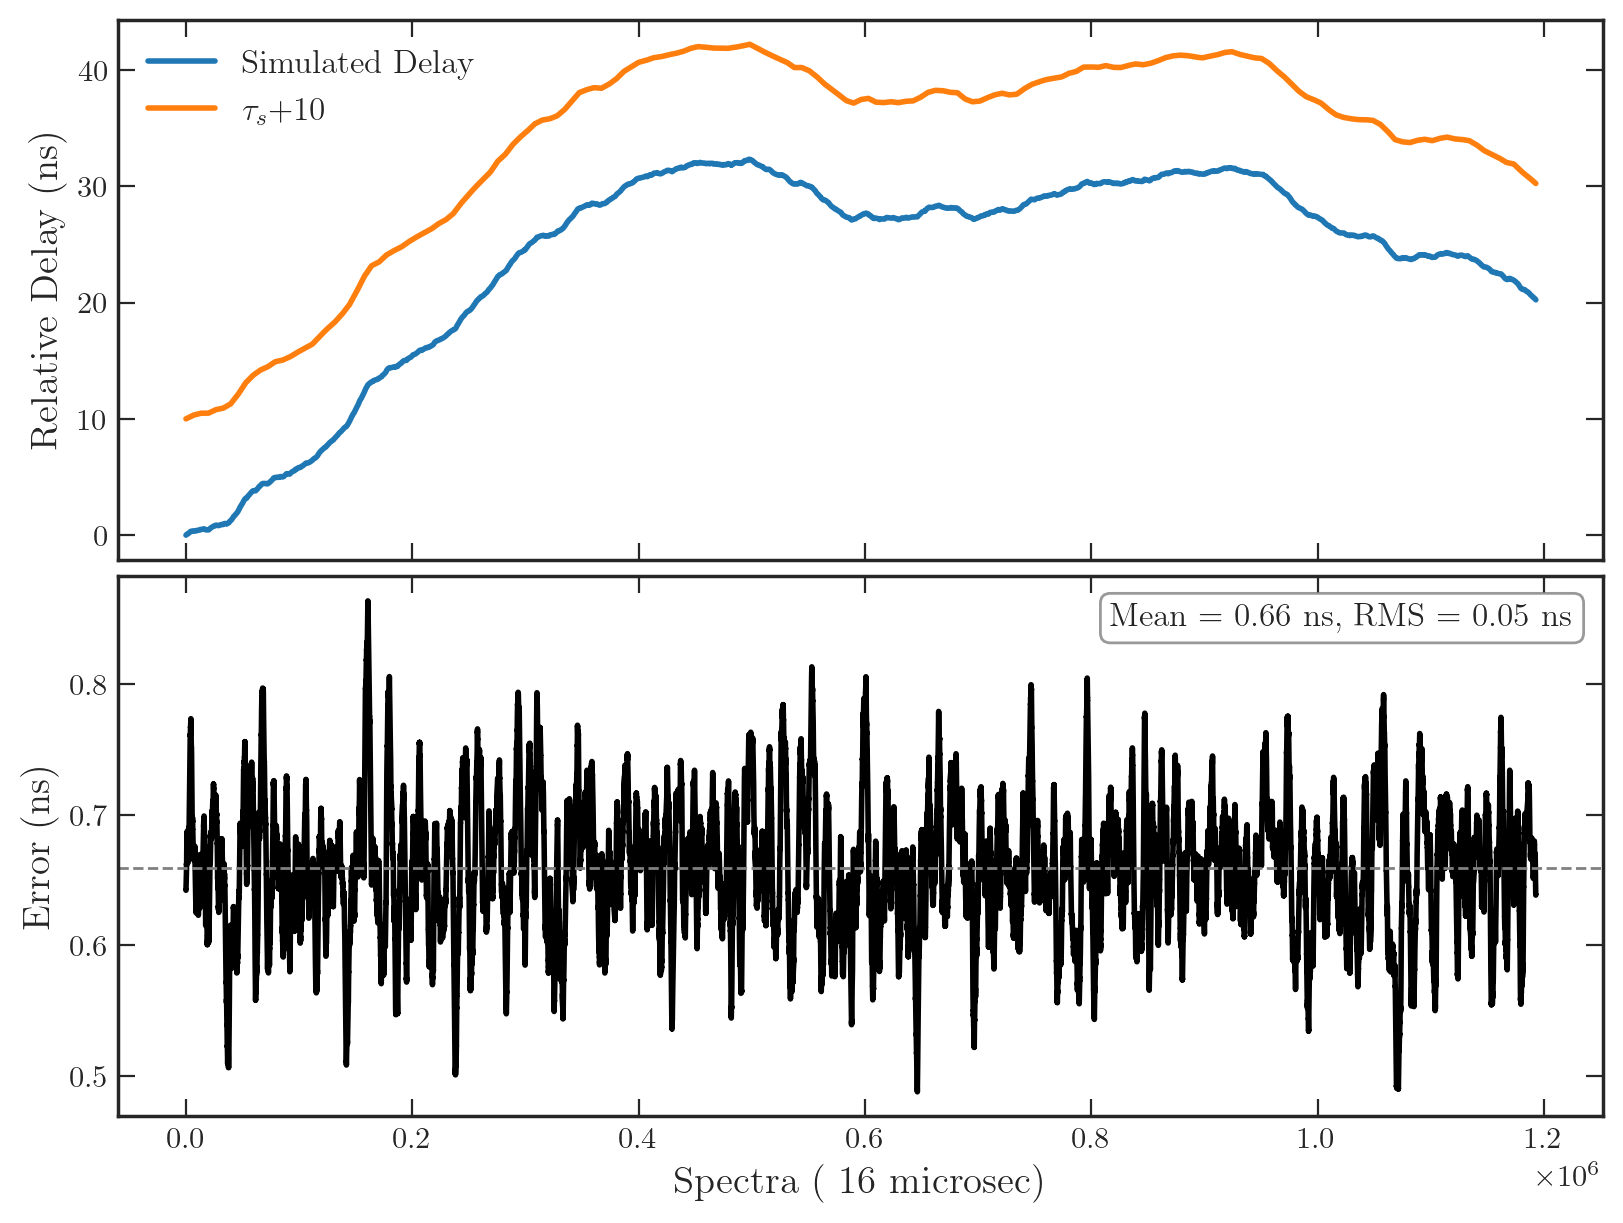

In [20]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True, constrained_layout=True)

ax[0].plot(y1 - y1[0], label=r"Simulated Delay", lw=2)
ax[0].plot(y2_interp-y2_interp[0] + 10, label=r"$\tau_s$+10", lw=2)
ax[0].set_ylabel('Relative Delay (ns)')
ax[0].legend(frameon=False)

ax[1].plot(res, 'k', lw=2)
ax[1].axhline(np.mean(res), color='gray', ls='--', lw=1)

#ax[1].set_title("Residual")
ax[1].set_xlabel("Spectra (~16 microsec)")
ax[1].set_ylabel("Error (ns)")

ax[1].text(
    0.98, 0.95,
    f"Mean = {np.mean(res):.2f} ns, RMS = {np.std(res):.2f} ns",
    transform=ax[1].transAxes,
    ha='right',
    va='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray")
)

for a in ax:
    a.tick_params(direction='in', top=True, right=True)

plt.savefig("/home/thomasb/albatros_analysis/scripts/orbcomm/paper_plots/fitted_taus.png", bbox_inches="tight")
plt.show()

In [13]:
print((4096*5 + 200)*4)
print(np.mean(res))
# print(np.std(res))
print((4096*5 + 200)*4  + np.mean(res))

82720
0.6594503567366721
82720.65945035673


In [79]:
#expected noise in time due to phase noise of 0.1 (ns)
print(1/(0.111) * 0.1/(2*np.pi))

0.14338283161432014


In [ ]:
print(1/(0.111) * 0.011/(2*np.pi))

0.015772111477575214


In [35]:
#now making visibilities with upsampled data

st = 0
blocksize = 1024
osamp = 64
block_dt = blocksize * 4096 / 250e6 * osamp
print("new channels are", new_channels[0] / osamp, "to", new_channels[-1]/osamp)
nblocks = new_spec1.shape[0] // blocksize - st
# print("new blocksize=", blocksize, "total nblocks=",nblocks)
# nblocks = 90
n = np.arange(0, blocksize)
# xc_avg_corrected = np.zeros((nblocks, len(new_channels)), dtype="complex128")
# xc_avg_uncorrected = np.zeros((nblocks, len(new_channels)), dtype="complex128")
# slopes = np.zeros(nblocks, dtype="float64")
# ph_noises = np.zeros(nblocks, dtype="float64")
# phases = np.zeros((nblocks, len(new_channels)), dtype="float64")
# phase_res = np.zeros((nblocks, len(new_channels)), dtype="float64")
# st = 4 * blocksize
# true_drift = -delays[st*blocksize*osamp:: blocksize * osamp][: len(slopes)]

# plt.plot(np.arange(nblocks)*block_dt, true_drift*4)
# plt.title("True drift")
# plt.ylabel("drift (ns)")
# plt.xlabel("Time (s)")
# plt.tight_layout()
# plt.show()


# nu = new_channels / 4096 / osamp
# # nu = np.arange(1830*osamp,1840*osamp)/4096/osamp

# print(nu)

# plt.title("METEOR M2-4 clock drift phase", fontsize=18)
# extent = [nu[0]*250,nu[-1]*250, nblocks*block_dt, 0]
# plt.imshow(np.angle(xc_avg_uncorrected),aspect='auto',cmap='RdBu',interpolation='None',extent=extent)
# plt.colorbar()
# plt.xlabel("Freq (MHz)")
# plt.ylabel("Time (s)")
# plt.tight_layout()
# plt.show()

new channels are 1832.1875 to 1836.171875


In [31]:
blocksize=2048
st=0
shift=0
nblocks = new_spec1.shape[0]//blocksize
xc_avg_uncorrected = np.zeros((nblocks, new_spec1.shape[1]), dtype="complex128")
ph_noises = np.zeros(nblocks, dtype="float64")
slopes = np.zeros(nblocks, dtype="float64")
print("nblocks", nblocks)
for i in range(nblocks):
    # fft and get a coarse guess
    ix = st * blocksize + i * blocksize
    y1 = new_spec1[ix : ix + blocksize, :]
    y2 = new_spec2[ix + shift : ix + shift + blocksize, :]
    xc_small = y1 * np.conj(y2)
    xc_avg_uncorrected[i, :] = np.mean(xc_small, axis=0)
    # ph = np.unwrap(np.angle(xc_avg_corrected[i, :]))
    # ph = np.unwrap(np.angle(xc_avg_uncorrected[i, 260:360]))
    # slope, const = np.polyfit(2 * np.pi * new_channels[260:360] / 4096 / osamp, ph, 1)
    # slopes[i] = slope
    # # phase_res[i]=ph - (2 * slope * np.pi * new_channels / 4096 / osamp + const)
    # ph_noises[i] = np.std(
    #     ph - (2 * slope * np.pi * new_channels[260:360] / 4096 / osamp + const)
    # ) 


nblocks 91


In [32]:
blocksize=2048
st=0
shift=0
nblocks = new_spec1.shape[0]//blocksize
xc_avg_uncorrected2 = np.zeros((nblocks, new_spec1.shape[1]), dtype="complex128")
ph_noises = np.zeros(nblocks, dtype="float64")
slopes = np.zeros(nblocks, dtype="float64")
print("nblocks", nblocks)
for i in range(nblocks):
    # fft and get a coarse guess
    ix = st * blocksize + i * blocksize
    y1 = rnew_spec1[ix : ix + blocksize, :]
    y2 = rnew_spec2[ix + shift : ix + shift + blocksize, :]
    xc_small = y1 * np.conj(y2)
    xc_avg_uncorrected2[i, :] = np.mean(xc_small, axis=0)

nblocks 91


In [33]:
rnew_spec1.shape

(187500, 256)

In [111]:
rnew2_spec1.shape

(187500, 256)

In [112]:
new_spec1.shape

(187500, 256)

In [113]:
blocksize=2048
st=0
shift=0
nblocks = new_spec1.shape[0]//blocksize
xc_avg_uncorrected3 = np.zeros((nblocks, new_spec1.shape[1]), dtype="complex128")
ph_noises = np.zeros(nblocks, dtype="float64")
slopes = np.zeros(nblocks, dtype="float64")
print("nblocks", nblocks)
for i in range(nblocks):
    # fft and get a coarse guess
    ix = st * blocksize + i * blocksize
    y1 = rnew2_spec1[ix : ix + blocksize, :]
    y2 = rnew2_spec2[ix + shift : ix + shift + blocksize, :]
    xc_small = y1 * np.conj(y2)
    xc_avg_uncorrected3[i, :] = np.mean(xc_small, axis=0)

nblocks 91


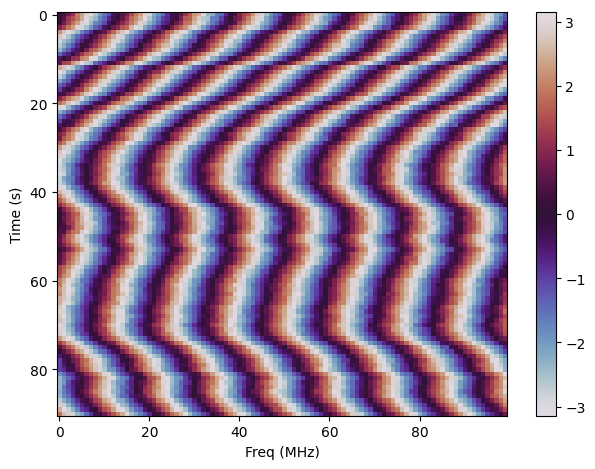

In [32]:
plt.imshow(np.angle(xc_avg_uncorrected)[:,70:70+100],aspect='auto',cmap='twilight',interpolation='None')
plt.colorbar()
plt.xlabel("Freq (MHz)")
plt.ylabel("Time (s)")
plt.tight_layout()
plt.show()

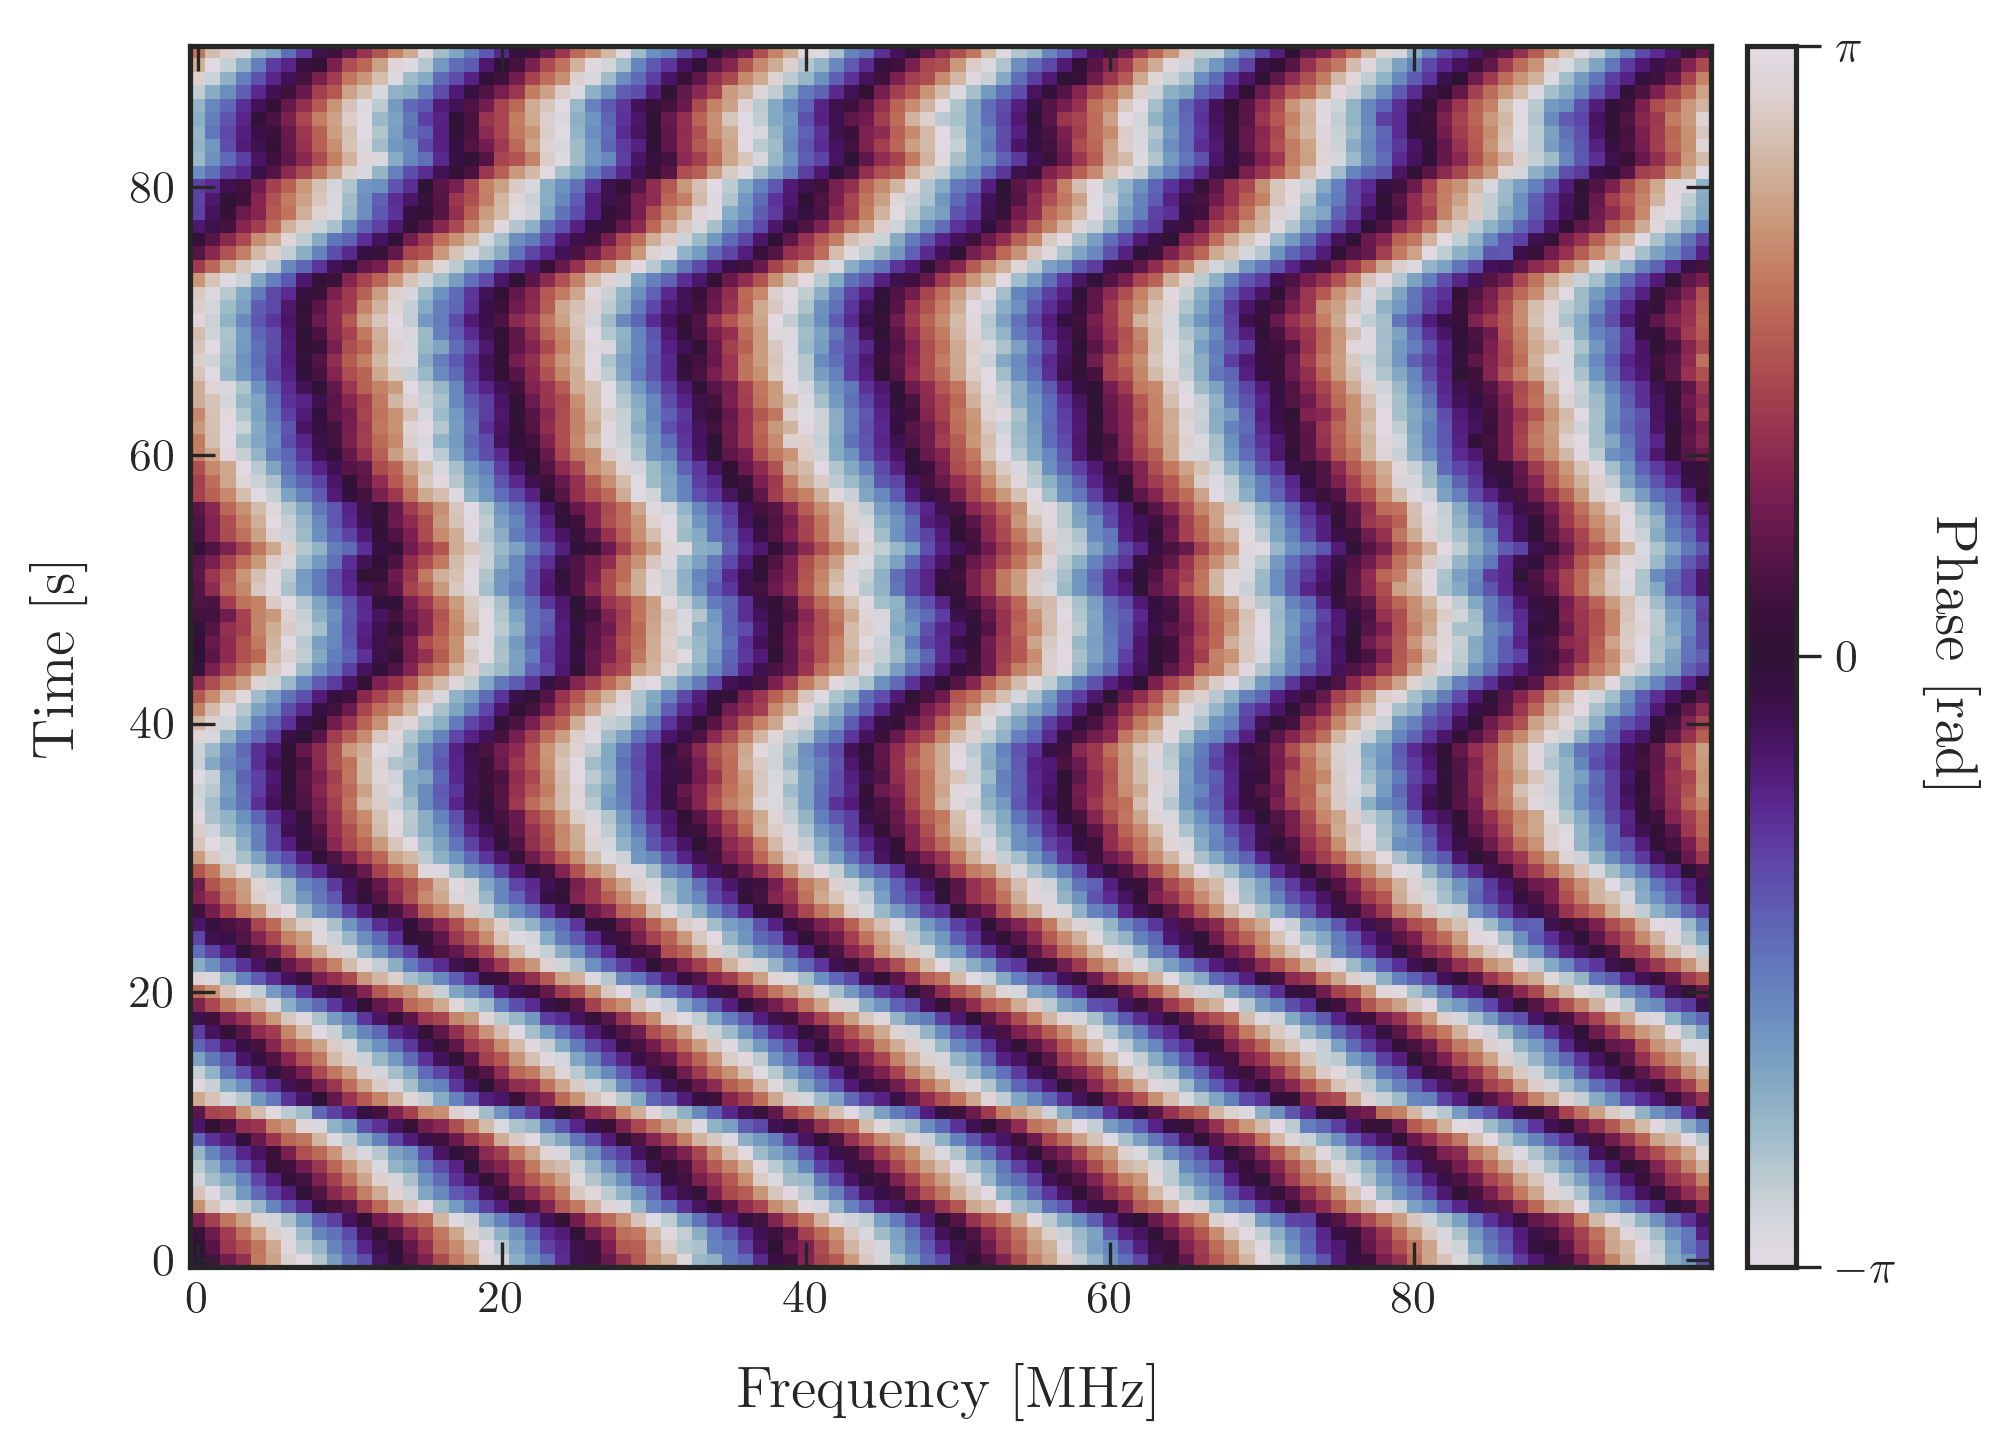

In [33]:
# Use a clean, high-resolution style
plt.style.use('seaborn-v0_8-ticks') # or 'default'
plt.rcParams.update({
    "text.usetex": True,           # Requires LaTeX installed on system
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,               # Base font size for paper
    "axes.labelsize": 14,          # Axis labels
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300              # High resolution for print
})

# Example data slicing (keeping your indices)
data = np.angle(xc_avg_uncorrected)[:, 70:170]

fig, ax = plt.subplots(figsize=(7, 5)) # Standard single-column width (~3.5in) or double (~7in)

im = ax.imshow(
    data, 
    aspect='auto', 
    cmap='twilight', 
    interpolation='nearest', # 'None' in plt.imshow defaults to 'nearest'
    origin='lower'           # Usually better for time/freq plots
)

# Axis Labels
ax.set_xlabel(r"Frequency [MHz]", labelpad=10)
ax.set_ylabel(r"Time [s]", labelpad=10)

# Colorbar Refinement
# Since it's phase, labeling in multiples of pi is standard for publications
cbar = fig.colorbar(im, ax=ax, pad=0.02, aspect=25)
cbar.set_label(r"Phase [rad]", rotation=270, labelpad=20)
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$0$", r"$\pi$"])

# Ticks and Layout
ax.tick_params(direction='in', top=True, right=True)
plt.tight_layout()

# Save for publication
# plt.savefig("phase_plot.pdf", bbox_inches='tight') 
plt.show()

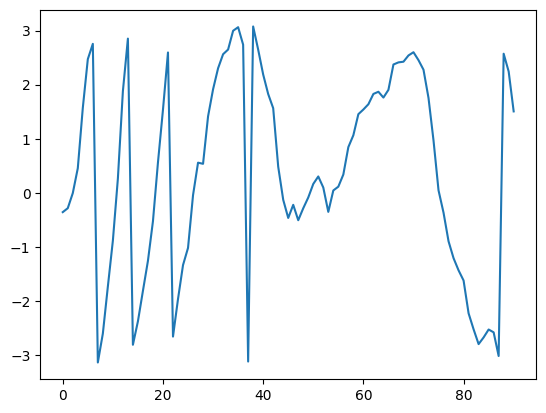

In [9]:
plt.plot(np.angle(xc_avg_uncorrected)[:,120])

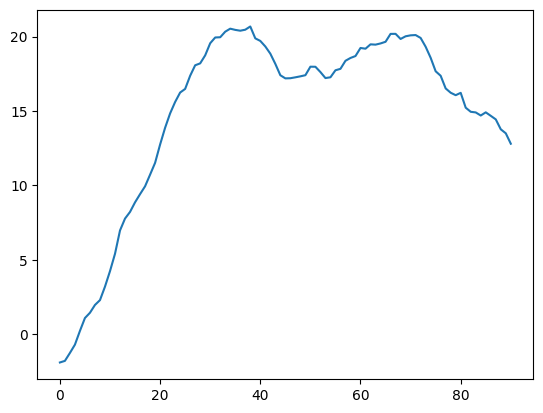

In [11]:
plt.plot(np.unwrap(np.angle(xc_avg_uncorrected)[:,130]))

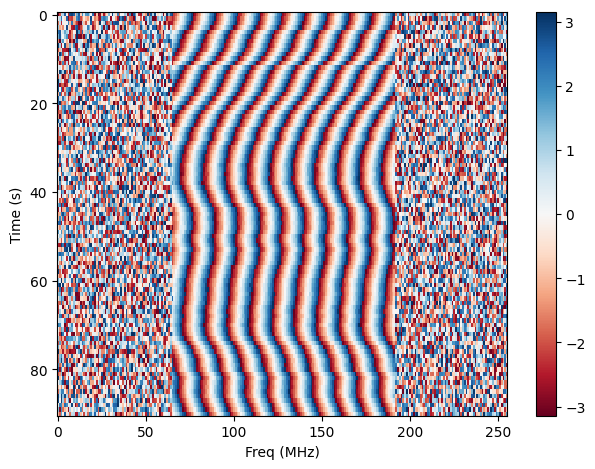

In [116]:
plt.imshow(np.angle(xc_avg_uncorrected2)[:,:],aspect='auto',cmap='RdBu',interpolation='None')
plt.colorbar()
plt.xlabel("Freq (MHz)")
plt.ylabel("Time (s)")
plt.tight_layout()
plt.show()

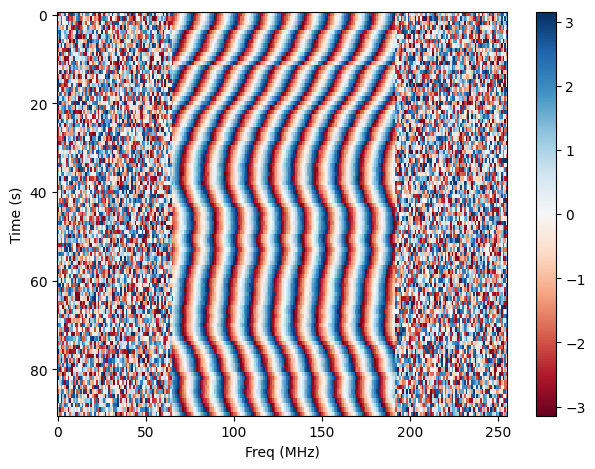

In [117]:
plt.imshow(np.angle(xc_avg_uncorrected3)[:,:],aspect='auto',cmap='RdBu',interpolation='None')
plt.colorbar()
plt.xlabel("Freq (MHz)")
plt.ylabel("Time (s)")
plt.tight_layout()
plt.show()

In [120]:
res = xc_avg_uncorrected3 - xc_avg_uncorrected2

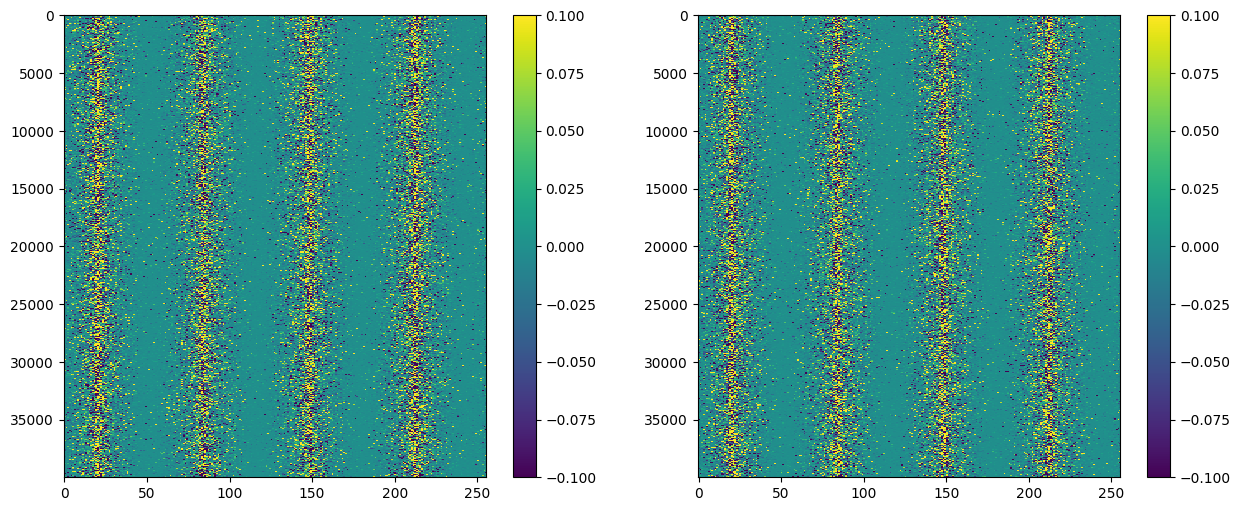

In [144]:
#OSAMP 4
fig=plt.gcf()
fig.set_size_inches(15,6)
cut = 10 * osamp
x1=new_spec1[10000:50000,:]
x2=rnew_spec1[10000:50000,:]
plt.subplot(121)
plt.imshow(np.real(x1-x2)/x1.real,aspect='auto',interpolation='none',vmax=0.1,vmin=-0.1)
plt.colorbar()
plt.subplot(122)
plt.imshow(np.imag(x1-x2)/x1.imag,aspect='auto',interpolation='none',vmax=0.1,vmin=-0.1)
plt.colorbar()
    

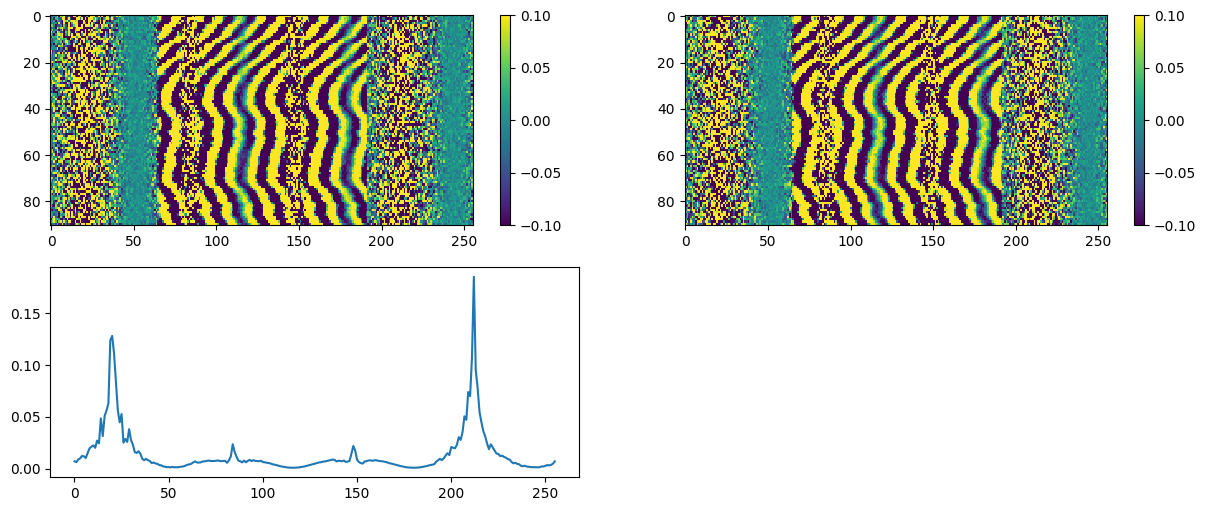

In [154]:
#OSAMP 4
fig=plt.gcf()
fig.set_size_inches(15,6)
cut = 10 * osamp
x1=xc_avg_uncorrected
x2=xc_avg_uncorrected2
plt.subplot(221)
plt.imshow(np.real(x1-x2),aspect='auto',interpolation='none',vmax=0.1,vmin=-0.1)
plt.colorbar()
plt.subplot(222)
plt.imshow(np.imag(x1-x2),aspect='auto',interpolation='none',vmax=0.1,vmin=-0.1)
plt.colorbar()
plt.subplot(223)
plt.plot(np.median(np.abs(np.real(x1-x2)/x1.real),axis=0))
    

In [24]:
new_channels.shape

(256,)

In [25]:
delay

NameError: name 'delay' is not defined

In [ ]:
freq = new_channels/osamp
true_phase = np.exp(1j*np.pi * freq[:

(70.0, 180.0)

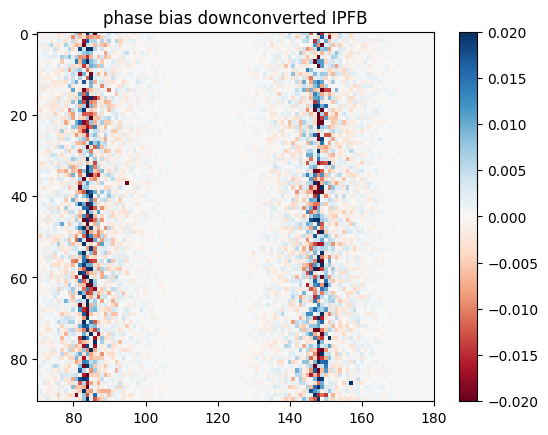

In [21]:
x1=xc_avg_uncorrected
x2=xc_avg_uncorrected2
res=np.angle(x1)-np.angle(x2)
plt.imshow(res,aspect='auto',interpolation='none',cmap='RdBu',vmin=-0.02,vmax=0.02)
plt.colorbar()
plt.title("phase bias downconverted IPFB")
plt.xlim(70,180)